In [ ]:
from dask_gateway import Gateway

gateway = Gateway()  # Uses values configured for the 2i2c Dask hub (recommended)

In [ ]:
options = gateway.cluster_options()
options

In [ ]:
# Create and scale gateway cluster
cluster = gateway.new_cluster(options)
cluster

In [ ]:
#Connect to the gateway cluster
client = cluster.get_client()
client

In [2]:
# connect to local cluster
#from dask.distributed import Client

#client = Client()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43673 instead
  warnings.warn(


In [3]:
import dask_ml.datasets
import dask_ml.cluster
import matplotlib.pyplot as plt

X, y = dask_ml.datasets.make_blobs(n_samples=10000000,
                                   chunks=1000000,
                                   random_state=0,
                                   centers=3,)
X = X.persist()
X

dask.array<concatenate, shape=(10000000, 2), dtype=float64, chunksize=(1000000, 2), chunktype=numpy.ndarray>

In [4]:
# km = dask_ml.cluster.KMeans(n_clusters=3, init_max_iter=2, oversampling_factor=10)
km = dask_ml.cluster.KMeans(
    n_clusters=3,
    init_max_iter=2,
    oversampling_factor=2,   # default is 2, not 10 — drop this back down
    max_iter=100,            # confirm this isn't set absurdly high
    tol=1e-4,                # make sure tolerance isn't too tight
    random_state=0,
)

km.fit(X)

,n_clusters,3
,init,'k-means||'
,oversampling_factor,2
,max_iter,100
,tol,0.0001
,precompute_distances,'auto'
,random_state,0
,copy_x,True
,n_jobs,1
,algorithm,'full'
,init_max_iter,2


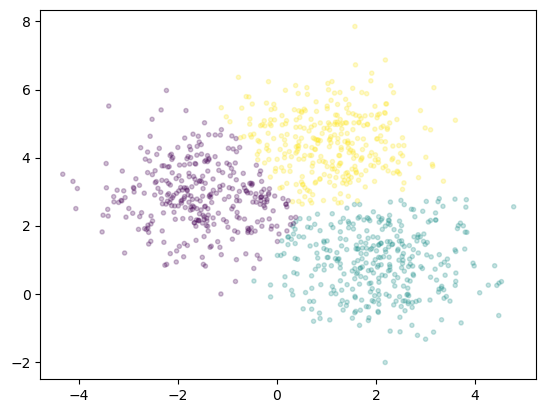

In [5]:
fig, ax = plt.subplots()
ax.scatter(X[::10000, 0], X[::10000, 1], marker='.', c=km.labels_[::10000],
           cmap='viridis', alpha=0.25);